# Training Data Generator — WarmStartPlanner

## Goal

Each data point is a tuple **(environment, start, goal → reference trajectory)**:

| Field | Shape | Meaning |
|---|---|---|
| `sdf` | `[1, H, W]` | Signed Distance Field of the environment |
| `q_start` | `[dof]` | Collision-free start joint angles |
| `q_goal` | `[dof]` | Collision-free goal joint angles |
| `q_traj` | `[T, dof]` | CHOMP reference trajectory (label) |
| `obstacles` | `[max_obs, 3]` | Obstacle positions and radii `(x, y, r)`, zero-padded |
| `n_obstacles` | scalar | Actual number of obstacles in this environment |

---

## Concept 1 — Meaningful Environments

**Circular obstacles within the robot workspace** (`sample_circular_obstacles`):
- Obstacles placed using **polar coordinates** (`r ≤ workspace_radius`) so they always
  lie within the robot's reachable area — not somewhere irrelevant outside it
- **Minimum separation** between obstacles prevents completely blocked environments
  where no feasible path exists
- Random count `[n_min, n_max]` and radii `[r_min, r_max]` for diversity

---

## Concept 2 — Meaningful Start/Goal Pairs

**Two-stage filter** (`sample_valid_pair`):
1. **Collision-free endpoints**: both `q_start` and `q_goal` must be reachable without collision
2. **Non-trivial**: at least one point along the straight joint-space line is in collision

Why the second filter matters: if the straight line is already collision-free, the task is trivial —
the network would only learn to output straight-line interpolations and never learn to navigate
around obstacles.

---

## Concept 3 — Data Combination

```
N_envs environments × pairs_per_env pairs per environment
         ↓
  CHOMP computes reference trajectory (with sinusoidal restarts)
         ↓
  Success filter: collision rate < success_threshold
         ↓
  Dataset = { sdf, q_start, q_goal, q_traj, obstacles, n_obstacles, metadata }
```

**Why N_envs × pairs_per_env?**
Multiple pairs per environment: the network sees the same environment from different start/goal
perspectives and learns to actually use the encoder output (not just interpolate start/goal).
Too many pairs per environment → risk of overfitting to few environments.
Rule of thumb: 3–10 pairs per environment.


In [1]:
# ---- Setup ----
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import SquareGrid, SE2, Obstacles
from simplearm.viz import RobotViewer


from losses import (
    compute_smoothness_cost,
    compute_trajectory_collision_cost,
    compute_collision_cost,
    compute_joint_limits_cost,
)
from utils import get_world_spheres_torch, query_sdf_differentiable
from models import build_bspline_interpolation_matrix

# ----------------------------
# Robot (central parameter definitions)
# ----------------------------
LINKLENGTHS  = [0.3, 0.4, 0.3]
SPHERE_RAD   = 0.08
GRID_LENGTH  = 2.5
N_VOX        = 128
T            = 50    # trajectory length (timesteps)
C            = 10    # number of B-spline waypoints (must match WarmStartPlanner)

robot            = RobotInfo.from_linklengths(LINKLENGTHS, sphere_rad=SPHERE_RAD)
DOF              = robot.n_dof
WORKSPACE_RADIUS = sum(LINKLENGTHS)  # 1.0 m — maximum reach of the arm

# Anatomically motivated joint limits:
#   Joint 0 (shoulder): full rotation [-π, π]
#   Joint 1 (elbow):    ≈155° — you can't fold your forearm fully into your upper arm
#   Joint 2 (wrist):    ≈155° — same physiological constraint
Q_MIN = np.array([-np.pi, -2.7, -2.7])
Q_MAX = np.array([ np.pi,  2.7,  2.7])

print(robot)
print(f"Workspace radius:  {WORKSPACE_RADIUS:.2f} m")
print(f"Grid:              {N_VOX}×{N_VOX}, length={GRID_LENGTH} m")
print(f"Trajectory:        T={T} steps, C={C} waypoints")
print(f"Joint limits:")
print(f"  Q_MIN = {np.round(Q_MIN, 3)}")
print(f"  Q_MAX = {np.round(Q_MAX, 3)}")

A Robot with the following properties:
  Link Lengths: [0.3 0.4 0.3]
  Number of Spheres: 10
  Mass per Link: [1. 1. 1.]
  Inertia per Link: [0.1 0.1 0.1]
  Number of ignore sphere pairs: 18
Workspace radius:  1.00 m
Grid:              128×128, length=2.5 m
Trajectory:        T=50 steps, C=10 waypoints
Joint limits:
  Q_MIN = [-3.142 -2.7   -2.7  ]
  Q_MAX = [3.142 2.7   2.7  ]


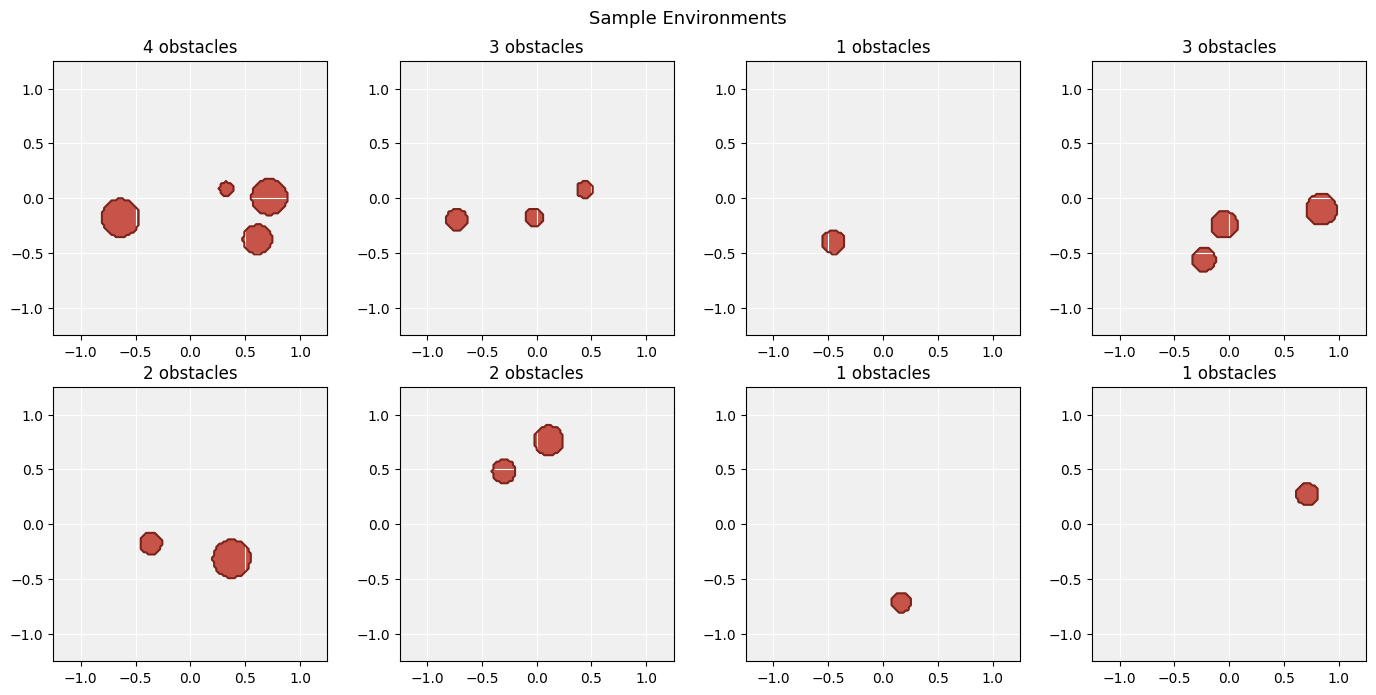

In [2]:
# ---- Environment Generation ----

def sample_circular_obstacles(
    n_obstacles: int = 3,
    r_min: float = 0.06,
    r_max: float = 0.18,
    workspace_radius: float = 1.0,
    min_separation: float = 0.05,
    rng: np.random.Generator = None,
    max_tries: int = 300,
) -> Obstacles:
    """
    Samples n_obstacles circular obstacles within the robot workspace.

    Placement via polar coordinates: r in [0.1, 0.85*workspace_radius], theta in [0, 2*pi].
    This guarantees all obstacles lie within the robot's reachable area.

    min_separation: minimum distance between obstacle surfaces.
    Prevents environments where no feasible path exists.
    """
    if rng is None:
        rng = np.random.default_rng()

    positions, radii = [], []

    for _ in range(n_obstacles):
        placed = False
        for _ in range(max_tries):
            r     = rng.uniform(0.15, workspace_radius * 0.85)
            theta = rng.uniform(0, 2 * np.pi)
            x, y  = r * np.cos(theta), r * np.sin(theta)
            rad   = rng.uniform(r_min, r_max)

            # Enforce minimum separation from already-placed obstacles
            ok = all(
                np.sqrt((x - px)**2 + (y - py)**2) >= rad + pr + min_separation
                for (px, py), pr in zip(positions, radii)
            )
            if ok:
                positions.append((x, y))
                radii.append(rad)
                placed = True
                break

        # Skip this obstacle if no valid position found within max_tries
        if not placed:
            pass

    if not positions:
        positions, radii = [(0.5, 0.0)], [0.1]

    xy = np.array(positions)
    return Obstacles(x=xy[:, 0], y=xy[:, 1], r=np.array(radii))


def build_sdf_tensor(
    obstacles: Obstacles,
    grid_length: float = 2.5,
    n_vox: int = 128,
) -> torch.Tensor:
    """Converts an Obstacles object into a [1, H, W] SDF tensor."""
    grid = SquareGrid(
        data=np.zeros((n_vox, n_vox)),
        length=grid_length,
        origin=SE2.identity(),
    )
    x = np.linspace(-grid_length / 2, grid_length / 2, n_vox)
    y = np.linspace(-grid_length / 2, grid_length / 2, n_vox)
    X, Y = np.meshgrid(x, y)
    for i in range(len(obstacles.r)):
        dist = np.sqrt((X - obstacles.x[i])**2 + (Y - obstacles.y[i])**2)
        grid.data[dist <= obstacles.r[i]] = 1.0
    sdf = grid.derive_sdf_from_voxels().data
    return torch.from_numpy(sdf).float().unsqueeze(0)  # [1, H, W]


def visualize_environment(sdf_tensor: torch.Tensor, grid_length: float = 2.5, ax=None):
    """Plots a single SDF environment (obstacles filled, boundary contoured)."""
    sdf = sdf_tensor.squeeze(0).numpy()
    xs  = np.linspace(-grid_length / 2, grid_length / 2, sdf.shape[1])
    ys  = np.linspace(-grid_length / 2, grid_length / 2, sdf.shape[0])
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_facecolor("#f0f0f0")
    ax.contourf(xs, ys, sdf, levels=[-1e6, 0], colors=["#c0392b"], alpha=0.85)
    ax.contour(xs, ys, sdf, levels=[0], colors=["#7b241c"], linewidths=1.5)
    ax.set_aspect("equal")
    ax.set_xlim(-grid_length / 2, grid_length / 2)
    ax.set_ylim(-grid_length / 2, grid_length / 2)
    ax.grid(True, color="white", linewidth=0.8)
    if own_fig:
        plt.tight_layout()
        plt.show()


# Preview: 8 sample environments
rng_preview = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flat:
    n_obs = rng_preview.integers(1, 5)
    obs   = sample_circular_obstacles(
        n_obstacles=n_obs, workspace_radius=WORKSPACE_RADIUS, rng=rng_preview
    )
    sdf = build_sdf_tensor(obs, GRID_LENGTH, N_VOX)
    visualize_environment(sdf, GRID_LENGTH, ax=ax)
    ax.set_title(f"{n_obs} obstacles")
plt.suptitle("Sample Environments", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# ---- Start / Goal Configuration Sampling ----

def is_collision_free(
    q: np.ndarray,
    sdf_tensor: torch.Tensor,
    robot: RobotInfo,
    grid_length: float = 2.5,
    clearance: float = 0.0,
) -> bool:
    """Returns True when all robot spheres at configuration q have SDF distance > clearance."""
    q_t     = torch.from_numpy(q).float().unsqueeze(0)
    sdf_hw  = sdf_tensor.squeeze(0)
    spheres = get_world_spheres_torch(q_t, robot)
    dists   = query_sdf_differentiable(sdf_hw, spheres.reshape(-1, 2), grid_length)
    return bool((dists > clearance).all())


def straight_line_blocked(
    q_start: np.ndarray,
    q_goal: np.ndarray,
    sdf_tensor: torch.Tensor,
    robot: RobotInfo,
    grid_length: float = 2.5,
    n_check: int = 9,
) -> bool:
    """
    Returns True if any interior point on the joint-space straight line is in collision.

    Why this filter is critical:
    If the straight line is collision-free, the task is trivial — the network would only
    learn to output straight-line interpolations without ever learning to avoid obstacles.
    Only non-trivial pairs provide a useful learning signal.
    """
    sdf_hw = sdf_tensor.squeeze(0)
    ts = np.linspace(0, 1, n_check + 2)[1:-1]  # interior points only (endpoints already validated)
    for t in ts:
        q_mid = (1 - t) * q_start + t * q_goal
        if not is_collision_free(q_mid, sdf_hw.unsqueeze(0), robot, grid_length):
            return True
    return False


def sample_valid_pair(
    sdf_tensor: torch.Tensor,
    robot: RobotInfo,
    q_min: np.ndarray,
    q_max: np.ndarray,
    grid_length: float = 2.5,
    clearance: float = 0.0,
    require_nontrivial: bool = True,
    n_check_midpoints: int = 9,
    max_tries: int = 300,
    rng: np.random.Generator = None,
) -> tuple[np.ndarray, np.ndarray] | None:
    """
    Samples a (q_start, q_goal) pair satisfying:
      1. Both configs are within joint limits and collision-free (+ optional clearance margin)
      2. (if require_nontrivial=True) The straight-line joint-space path is blocked

    Returns None if no valid pair is found within max_tries attempts.

    Args:
      clearance:          Minimum SDF distance required for all spheres (>0 = more conservative)
      require_nontrivial: Only accept pairs where the straight line is blocked
      n_check_midpoints:  Number of interior points checked for the non-trivial filter
      max_tries:          Maximum number of sampling attempts
    """
    if rng is None:
        rng = np.random.default_rng()

    for _ in range(max_tries):
        q_start = rng.uniform(q_min, q_max)
        q_goal  = rng.uniform(q_min, q_max)

        if not is_collision_free(q_start, sdf_tensor, robot, grid_length, clearance):
            continue
        if not is_collision_free(q_goal, sdf_tensor, robot, grid_length, clearance):
            continue
        if require_nontrivial and not straight_line_blocked(
            q_start, q_goal, sdf_tensor, robot, grid_length, n_check_midpoints
        ):
            continue

        return q_start, q_goal

    return None


# --- Sanity check on a sample environment ---
rng_check = np.random.default_rng(1)
obs_check = sample_circular_obstacles(n_obstacles=3, workspace_radius=WORKSPACE_RADIUS, rng=rng_check)
sdf_check = build_sdf_tensor(obs_check, GRID_LENGTH, N_VOX)

result = sample_valid_pair(sdf_check, robot, Q_MIN, Q_MAX, GRID_LENGTH, require_nontrivial=True, rng=rng_check)
if result:
    q_s, q_g = result
    print(f"Valid pair found:")
    print(f"  q_start = {np.round(q_s, 3)}")
    print(f"  q_goal  = {np.round(q_g, 3)}")
    print(f"  Start collision-free:     {is_collision_free(q_s, sdf_check, robot, GRID_LENGTH)}")
    print(f"  Goal collision-free:      {is_collision_free(q_g, sdf_check, robot, GRID_LENGTH)}")
    print(f"  Straight line blocked:    {straight_line_blocked(q_s, q_g, sdf_check, robot, GRID_LENGTH)}")
else:
    print("No valid pair found within 300 attempts.")

Valid pair found:
  q_start = [-1.38  -0.08   2.596]
  q_goal  = [2.901 1.214 0.223]
  Start collision-free:     True
  Goal collision-free:      True
  Straight line blocked:    True


In [4]:
# ---- CHOMP — Reference Trajectory ----

def compute_reference_trajectory(
    q_start: np.ndarray,
    q_goal: np.ndarray,
    sdf_tensor: torch.Tensor,
    robot: RobotInfo,
    T: int = 50,
    C: int = 10,
    n_iter: int = 500,
    lr: float = 0.03,
    w_smooth: float = 0.001,
    w_coll: float = 5.0,
    w_vel: float = 400.0,
    w_jl: float = 50.0,
    eps: float = 0.15,
    v_max: float = 0.15,
    n_restarts: int = 3,
    grid_length: float = 2.5,
    success_threshold: float = 0.02,
    q_min: np.ndarray = None,
    q_max: np.ndarray = None,
) -> tuple[np.ndarray, bool]:
    """
    B-Spline CHOMP with sinusoidal restarts.

    Returns (q_traj [T, dof], success).
    success=True when collision rate < success_threshold (e.g. < 2%).

    Args:
      n_restarts:         Number of restarts with increasing random perturbation (recommended: 3-5)
      success_threshold:  Maximum allowed fraction of colliding sphere-timestep pairs
      w_coll:             Collision weight (normalized by B*T inside compute_trajectory_collision_cost)
      w_vel:              Velocity limit weight (prevents tunneling through obstacles between frames)
      v_max:              Maximum joint angle change [rad] per timestep
      w_jl:               Joint limit penalty weight
      q_min / q_max:      Joint limits [dof]; if None, joint limit cost is skipped
    """
    q_s = torch.tensor(q_start, dtype=torch.float32)
    q_g = torch.tensor(q_goal,  dtype=torch.float32)
    dof = len(q_start)

    sdf_batch    = sdf_tensor.unsqueeze(0)  # [1, 1, H, W]
    M            = build_bspline_interpolation_matrix(T, C, degree=3)
    t_inner      = torch.linspace(0, 1, C)[1:-1]
    straight     = q_s * (1 - t_inner[:, None]) + q_g * t_inner[:, None]
    sin_envelope = torch.sin(torch.pi * t_inner)

    q_min_t = torch.tensor(q_min, dtype=torch.float32) if q_min is not None else None
    q_max_t = torch.tensor(q_max, dtype=torch.float32) if q_max is not None else None

    best_traj, best_coll_rate = None, float("inf")

    for restart in range(n_restarts):
        if restart == 0:
            init = straight.clone()
        else:
            direction    = torch.randn(dof)
            direction    = direction / (direction.norm() + 1e-8)
            amplitude    = 0.6 * restart
            perturbation = amplitude * sin_envelope[:, None] * direction[None, :]
            init         = straight + perturbation

        q_inner = init.detach().clone().requires_grad_(True)
        opt     = torch.optim.Adam([q_inner], lr=lr)

        for _ in range(n_iter):
            opt.zero_grad()
            waypoints   = torch.cat([q_s.unsqueeze(0), q_inner, q_g.unsqueeze(0)], dim=0)
            q_traj      = M @ waypoints  # [T, dof]

            loss_smooth = compute_smoothness_cost(q_traj.unsqueeze(0), dt=1.0, weight=w_smooth)
            loss_coll   = compute_trajectory_collision_cost(
                q_traj.unsqueeze(0), sdf_batch, robot,
                grid_length=grid_length, eps=eps, weight=w_coll,
            )
            vel         = q_traj[1:] - q_traj[:-1]
            loss_vel    = w_vel * torch.relu(vel.abs() - v_max).pow(2).sum()

            if q_min_t is not None:
                loss_jl = compute_joint_limits_cost(q_traj, q_min_t, q_max_t, weight=w_jl)
            else:
                loss_jl = 0.0

            (loss_smooth + loss_coll + loss_vel + loss_jl).backward()
            opt.step()

        with torch.no_grad():
            wp      = torch.cat([q_s.unsqueeze(0), q_inner, q_g.unsqueeze(0)], dim=0)
            q_final = M @ wp  # [T, dof]

        sdf_hw    = sdf_tensor.squeeze(0)
        spheres   = get_world_spheres_torch(q_final, robot)
        dists     = query_sdf_differentiable(sdf_hw, spheres.reshape(-1, 2), grid_length)
        coll_rate = (dists < 0).float().mean().item()

        if coll_rate < best_coll_rate:
            best_coll_rate = coll_rate
            best_traj      = q_final.numpy()

    success = best_coll_rate <= success_threshold
    return best_traj, success

In [16]:
# ---- Dataset Assembly ----

def generate_dataset(
    # --- Dataset size ---
    N_envs: int          = 200,
    pairs_per_env: int   = 5,
    # --- Robot ---
    robot: RobotInfo     = None,
    sphere_rad: float    = 0.08,
    q_min: np.ndarray    = None,
    q_max: np.ndarray    = None,
    # --- Environments ---
    n_obstacles_range: tuple[int, int] = (1, 4),
    r_range: tuple[float, float]       = (0.06, 0.18),
    workspace_radius: float            = 1.0,
    min_separation: float              = 0.05,
    # --- Configuration pairs ---
    clearance: float = None,   # defaults to sphere_rad — ensures sphere SURFACE is outside obstacles
    require_nontrivial: bool    = True,
    n_check_midpoints: int      = 9,
    max_pair_tries: int         = 300,
    # --- CHOMP ---
    T: int                      = 50,
    C: int                      = 10,
    chomp_n_iter: int           = 500,
    chomp_lr: float             = 0.03,
    chomp_w_smooth: float       = 0.001,
    chomp_w_coll: float         = 5.0,
    chomp_w_vel: float          = 400.0,
    chomp_w_jl: float           = 50.0,
    chomp_eps: float            = 0.15,
    chomp_v_max: float          = 0.15,
    chomp_n_restarts: int       = 3,
    success_threshold: float    = 0.02,
    # --- Grid ---
    grid_length: float          = 2.5,
    n_vox: int                  = 128,
    # --- Misc ---
    seed: int                   = 42,
    save_path: str              = "data/training_dataset.pt",
) -> dict:
    """
    Full data generation pipeline for the WarmStartPlanner.

    Pipeline:
      1. For each of N_envs environments:
           a. Sample circular obstacles (workspace-aware, with min_separation)
           b. Build SDF tensor [1, H, W]
      2. For each environment, repeat pairs_per_env times:
           a. sample_valid_pair  (collision-free + non-trivial filter)
           b. compute_reference_trajectory  (CHOMP with restarts + joint limit cost)
           c. Accept only if CHOMP succeeded  (coll_rate < success_threshold)
      3. Pack and save as a torch dict.

    Dataset fields:
      sdf:         [N, 1, H, W]      Environments (SDF grids)
      q_start:     [N, dof]          Start configurations
      q_goal:      [N, dof]          Goal configurations
      q_traj:      [N, T, dof]       CHOMP reference trajectories (labels)
      obstacles:   [N, max_obs, 3]   Obstacle data (x, y, r), zero-padded per sample
      n_obstacles: [N]               Actual obstacle count per sample
      metadata:    dict              Robot params, grid params, dataset params
    """
    # SDF queried at sphere centers → clearance >= sphere_rad ensures sphere surface is outside obstacles
    if clearance is None:
        clearance = sphere_rad

    rng = np.random.default_rng(seed)

    all_sdfs, all_q_starts, all_q_goals, all_trajs = [], [], [], []
    all_obs_x, all_obs_y, all_obs_r, all_n_obs    = [], [], [], []
    n_attempted, n_no_pair, n_chomp_failed         = 0, 0, 0

    for _ in tqdm(range(N_envs), desc="Generating dataset"):
        n_obs      = int(rng.integers(n_obstacles_range[0], n_obstacles_range[1] + 1))
        obstacles  = sample_circular_obstacles(
            n_obstacles=n_obs, r_min=r_range[0], r_max=r_range[1],
            workspace_radius=workspace_radius, min_separation=min_separation, rng=rng,
        )
        sdf_tensor = build_sdf_tensor(obstacles, grid_length, n_vox)  # [1, H, W]

        for _ in range(pairs_per_env):
            n_attempted += 1

            pair = sample_valid_pair(
                sdf_tensor, robot, q_min, q_max,
                grid_length=grid_length, clearance=clearance,
                require_nontrivial=require_nontrivial,
                n_check_midpoints=n_check_midpoints,
                max_tries=max_pair_tries, rng=rng,
            )
            if pair is None:
                n_no_pair += 1
                continue

            q_start, q_goal = pair
            q_traj, success = compute_reference_trajectory(
                q_start, q_goal, sdf_tensor, robot,
                T=T, C=C,
                n_iter=chomp_n_iter, lr=chomp_lr,
                w_smooth=chomp_w_smooth, w_coll=chomp_w_coll,
                w_vel=chomp_w_vel, w_jl=chomp_w_jl,
                eps=chomp_eps, v_max=chomp_v_max,
                n_restarts=chomp_n_restarts,
                grid_length=grid_length,
                success_threshold=success_threshold,
                q_min=q_min, q_max=q_max,
            )
            if not success:
                n_chomp_failed += 1
                continue

            all_sdfs.append(sdf_tensor)
            all_q_starts.append(torch.from_numpy(q_start).float())
            all_q_goals.append(torch.from_numpy(q_goal).float())
            all_trajs.append(torch.from_numpy(q_traj).float())
            # Store obstacle geometry for later visualization (not used for training)
            all_obs_x.append(obstacles.x.copy())
            all_obs_y.append(obstacles.y.copy())
            all_obs_r.append(obstacles.r.copy())
            all_n_obs.append(len(obstacles.r))

    N_total = len(all_sdfs)
    print(f"\n{'─'*48}")
    print(f"  Attempts total:          {n_attempted}")
    print(f"  No valid pair found:     {n_no_pair}")
    print(f"  CHOMP did not converge:  {n_chomp_failed}")
    print(f"  Successful samples:      {N_total}  ({100*N_total/max(n_attempted,1):.1f}%)")
    print(f"{'─'*48}")

    if N_total == 0:
        print("WARNING: No data points generated. Check parameters.")
        return {}

    # Pack obstacle data: zero-pad to max_n_obs per sample → [N, max_obs, 3]
    max_n_obs    = max(all_n_obs)
    obs_padded   = torch.zeros(N_total, max_n_obs, 3)
    for i, (x, y, r) in enumerate(zip(all_obs_x, all_obs_y, all_obs_r)):
        n = len(x)
        obs_padded[i, :n, 0] = torch.from_numpy(x).float()
        obs_padded[i, :n, 1] = torch.from_numpy(y).float()
        obs_padded[i, :n, 2] = torch.from_numpy(r).float()

    dataset = {
        "sdf":         torch.stack(all_sdfs),
        "q_start":     torch.stack(all_q_starts),
        "q_goal":      torch.stack(all_q_goals),
        "q_traj":      torch.stack(all_trajs),
        "obstacles":   obs_padded,
        "n_obstacles": torch.tensor(all_n_obs, dtype=torch.long),
        "metadata": {
            "N": N_total, "T": T, "C": C,
            "grid_length": grid_length, "n_vox": n_vox,
            "dof":         robot.n_dof,
            "linklengths": list(robot.linklengths),
            "sphere_rad":  sphere_rad,
            "q_min":       q_min.tolist() if q_min is not None else None,
            "q_max":       q_max.tolist() if q_max is not None else None,
        },
    }

    os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
    torch.save(dataset, save_path)
    size_mb = os.path.getsize(save_path) / 1e6
    print(f"  Saved: {save_path}  ({size_mb:.1f} MB)")
    return dataset


# ============================================================
# Set parameters here, then run this cell
# ============================================================
success_threshold = 0.01
dataset = generate_dataset(
    N_envs            = 10,
    pairs_per_env     = 5,
    robot             = robot,
    sphere_rad        = SPHERE_RAD,
    q_min             = Q_MIN,
    q_max             = Q_MAX,
    n_obstacles_range = (1, 3),
    r_range           = (0.06, 0.18),
    workspace_radius  = WORKSPACE_RADIUS,
    require_nontrivial= True,
    T                 = T,
    C                 = C,
    chomp_n_restarts  = 3,
    chomp_n_iter      = 500,
    chomp_w_jl        = 50.0,
    success_threshold = success_threshold,
    grid_length       = GRID_LENGTH,
    n_vox             = N_VOX,
    seed              = 42,
    save_path         = "data/training_dataset.pt",
)

Generating dataset:   0%|          | 0/10 [00:00<?, ?it/s]


────────────────────────────────────────────────
  Attempts total:          50
  No valid pair found:     8
  CHOMP did not converge:  21
  Successful samples:      21  (42.0%)
────────────────────────────────────────────────
  Saved: data/training_dataset.pt  (1.4 MB)


Dataset: 21 samples
  sdf:         (21, 1, 128, 128)
  q_start:     (21, 3)
  q_goal:      (21, 3)
  q_traj:      (21, 50, 3)
  obstacles:   (21, 3, 3)  (x, y, r — zero-padded)
  n_obstacles: (21,)

Robot metadata:
  linklengths: [0.3, 0.4, 0.3]
  sphere_rad:  0.08


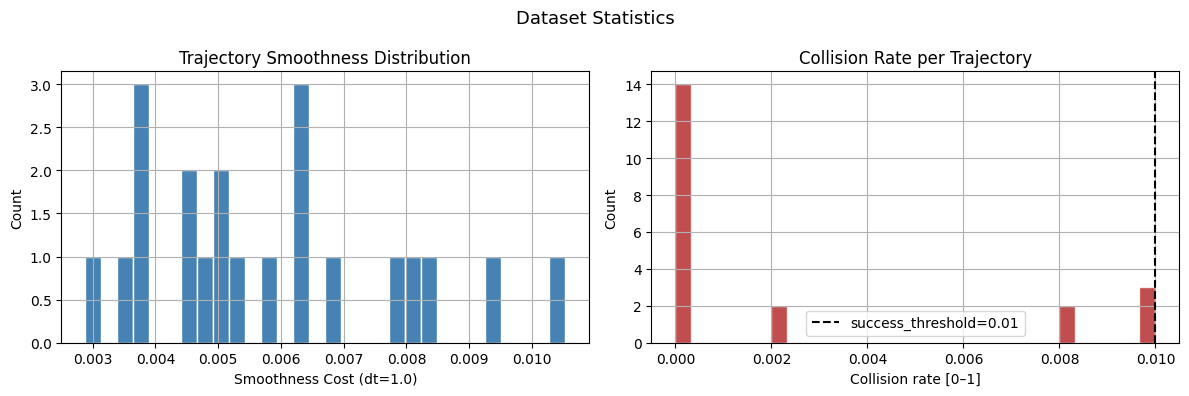


Collision rate:  mean=0.002  max=0.010
Smoothness:      mean=0.0059  max=0.0105


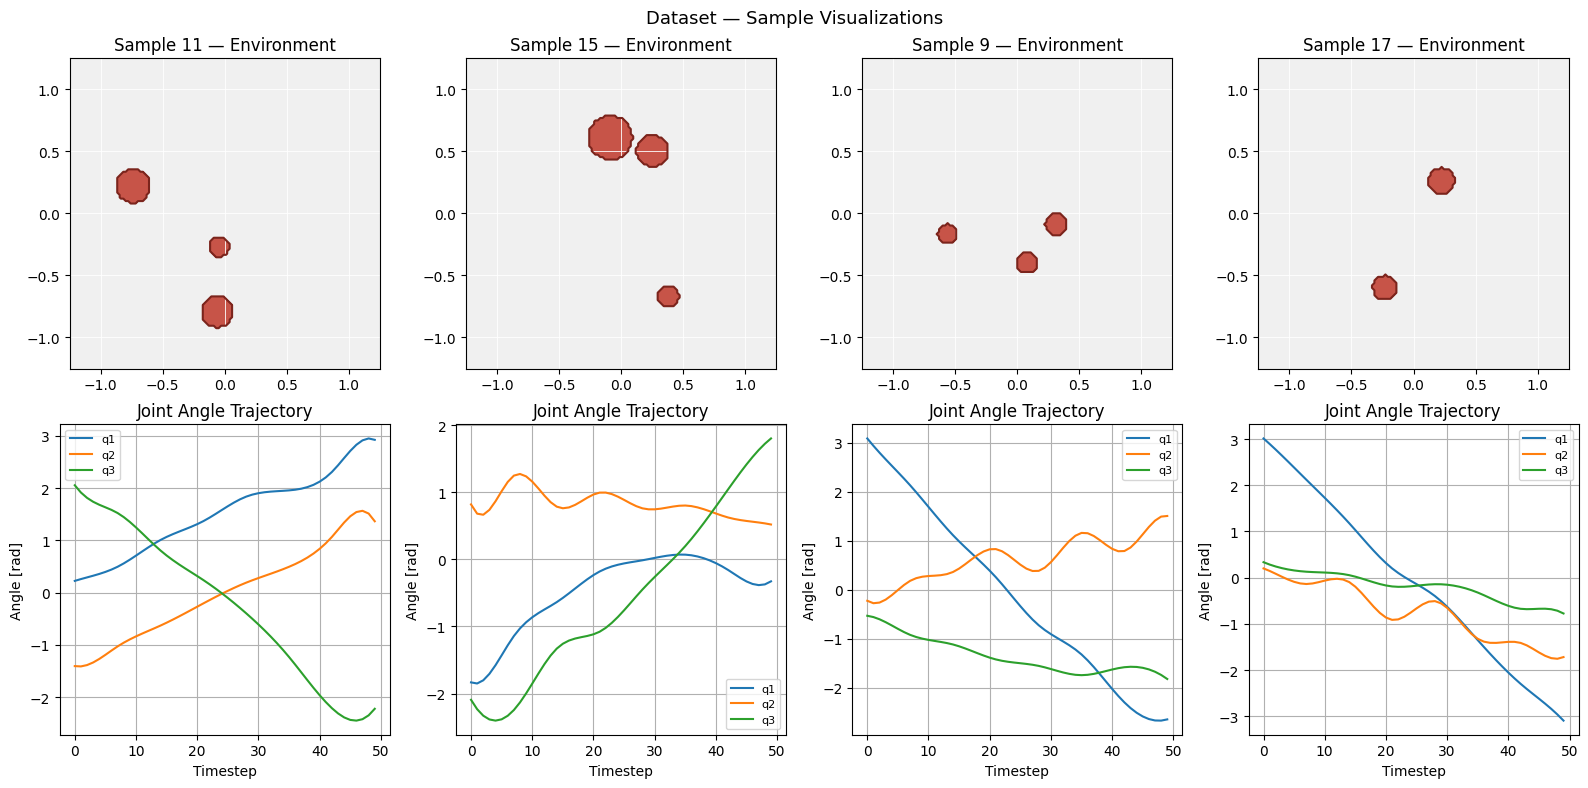

In [17]:
# ---- Dataset Statistics & Sample Visualization ----

if not dataset:
    print("No dataset available.")
else:
    N   = dataset["metadata"]["N"]
    dof = dataset["metadata"]["dof"]

    print(f"Dataset: {N} samples")
    print(f"  sdf:         {tuple(dataset['sdf'].shape)}")
    print(f"  q_start:     {tuple(dataset['q_start'].shape)}")
    print(f"  q_goal:      {tuple(dataset['q_goal'].shape)}")
    print(f"  q_traj:      {tuple(dataset['q_traj'].shape)}")
    print(f"  obstacles:   {tuple(dataset['obstacles'].shape)}  (x, y, r — zero-padded)")
    print(f"  n_obstacles: {tuple(dataset['n_obstacles'].shape)}")
    print(f"\nRobot metadata:")
    print(f"  linklengths: {dataset['metadata']['linklengths']}")
    print(f"  sphere_rad:  {dataset['metadata']['sphere_rad']}")

    # --- Smoothness distribution ---
    smoothness = [
        compute_smoothness_cost(dataset["q_traj"][i].unsqueeze(0), dt=1.0).item()
        for i in range(min(N, 500))
    ]

    # --- Collision rate across dataset ---
    coll_rates = []
    for i in range(min(N, 100)):
        q_t   = dataset["q_traj"][i]
        sdf_i = dataset["sdf"][i, 0]
        sp    = get_world_spheres_torch(q_t, robot)
        dist  = query_sdf_differentiable(sdf_i, sp.reshape(-1, 2), GRID_LENGTH)
        coll_rates.append((dist < 0).float().mean().item())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(smoothness, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Smoothness Cost (dt=1.0)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Trajectory Smoothness Distribution")
    axes[0].grid(True)

    axes[1].hist(coll_rates, bins=30, color="firebrick", edgecolor="white", alpha=0.8)
    axes[1].axvline(success_threshold, color="k", linestyle="--", label=f"success_threshold={success_threshold}")
    axes[1].set_xlabel("Collision rate [0–1]")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Collision Rate per Trajectory")
    axes[1].legend()
    axes[1].grid(True)
    plt.suptitle("Dataset Statistics", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\nCollision rate:  mean={np.mean(coll_rates):.3f}  max={np.max(coll_rates):.3f}")
    print(f"Smoothness:      mean={np.mean(smoothness):.4f}  max={np.max(smoothness):.4f}")

    # --- 4 sample visualizations ---
    idxs = np.random.default_rng(99).choice(N, min(4, N), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for col, idx in enumerate(idxs):
        sdf_np  = dataset["sdf"][idx, 0].numpy()
        q_traj  = dataset["q_traj"][idx].numpy()
        q_start = dataset["q_start"][idx].numpy()

        ax = axes[0, col]
        xs = np.linspace(-GRID_LENGTH / 2, GRID_LENGTH / 2, sdf_np.shape[1])
        ys = np.linspace(-GRID_LENGTH / 2, GRID_LENGTH / 2, sdf_np.shape[0])
        ax.set_facecolor("#f0f0f0")
        ax.contourf(xs, ys, sdf_np, levels=[-1e6, 0], colors=["#c0392b"], alpha=0.85)
        ax.contour(xs, ys, sdf_np, levels=[0], colors=["#7b241c"], linewidths=1.5)
        ax.set_aspect("equal")
        ax.set_title(f"Sample {idx} — Environment")
        ax.grid(True, color="white", linewidth=0.6)

        ax = axes[1, col]
        for d in range(dof):
            ax.plot(q_traj[:, d], label=f"q{d+1}")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Angle [rad]")
        ax.set_title("Joint Angle Trajectory")
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.suptitle("Dataset — Sample Visualizations", fontsize=13)
    plt.tight_layout()
    plt.show()

In [24]:
# ---- Visualize a sample from training_dataset ----

dataset = torch.load("data/training_dataset.pt", weights_only=False)
N_ds = dataset["metadata"]["N"]

# Reconstruct robot exactly as used during data generation
robot_ds = RobotInfo.from_linklengths(
    dataset["metadata"]["linklengths"],
    sphere_rad=dataset["metadata"]["sphere_rad"],
)

# Set a specific index or None for a random sample
SAMPLE_IDX = None
if SAMPLE_IDX is None:
    SAMPLE_IDX = torch.randint(0, N_ds, (1,)).item()

sdf_sample    = dataset["sdf"][SAMPLE_IDX]
q_start_np    = dataset["q_start"][SAMPLE_IDX].numpy()
q_goal_np     = dataset["q_goal"][SAMPLE_IDX].numpy()
q_traj_ref_np = dataset["q_traj"][SAMPLE_IDX].numpy()  # [T, dof] — CHOMP label

# Reconstruct Obstacles from stored geometry
n_obs     = dataset["n_obstacles"][SAMPLE_IDX].item()
obs_data  = dataset["obstacles"][SAMPLE_IDX]            # [max_obs, 3]
obstacles_sample = Obstacles(
    x=obs_data[:n_obs, 0].numpy(),
    y=obs_data[:n_obs, 1].numpy(),
    r=obs_data[:n_obs, 2].numpy(),
)

print(f"Sample {SAMPLE_IDX} / {N_ds}")
print(f"  q_start:     {np.round(q_start_np, 3)}")
print(f"  q_goal:      {np.round(q_goal_np, 3)}")
print(f"  obstacles:   {n_obs}  x={np.round(obs_data[:n_obs,0].numpy(),2)}  r={np.round(obs_data[:n_obs,2].numpy(),2)}")
print(f"  Robot:       linklengths={dataset['metadata']['linklengths']}  sphere_rad={dataset['metadata']['sphere_rad']}")

# SDF plot
# sdf_np = sdf_sample[0].numpy()
# gl     = dataset["metadata"]["grid_length"]
# fig, ax = plt.subplots(figsize=(5, 5))
# xs = np.linspace(-gl / 2, gl / 2, sdf_np.shape[1])
# ys = np.linspace(-gl / 2, gl / 2, sdf_np.shape[0])
# ax.set_facecolor("#f0f0f0")
# ax.contourf(xs, ys, sdf_np, levels=[-1e6, 0], colors=["#c0392b"], alpha=0.85)
# ax.contour(xs, ys, sdf_np, levels=[0], colors=["#7b241c"], linewidths=1.5)
# ax.set_aspect("equal")
# ax.set_title(f"Sample {SAMPLE_IDX} — Environment (SDF)")
# ax.grid(True, color="white")
# plt.tight_layout()
# plt.show()

# Animate reference trajectory with the dataset robot and obstacles
print("\nCHOMP reference trajectory from dataset:")
viz_ref = RobotViewer(q_traj_ref_np, robot_ds, obstacles=obstacles_sample)
viz_ref.plot()


Sample 18 / 21
  q_start:     [-2.815 -0.86  -0.027]
  q_goal:      [-1.24   1.308  1.201]
  obstacles:   2  x=[ 0.22 -0.23]  r=[0.1 0.1]
  Robot:       linklengths=[0.3, 0.4, 0.3]  sphere_rad=0.08

CHOMP reference trajectory from dataset:
⠙ Plotting robot... (0:00:00.14) 